# Parkinson's Disease Prediction
Dataset: UCI Parkinson's Voice Measurements  
Target: `status` (1=Parkinson's, 0=Healthy)

## 1 · Imports & Data Load

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix, roc_curve)
from xgboost import XGBClassifier
import joblib, json

df = pd.read_csv("../data/parkinsons.csv")
print(df.shape)
print("Class balance:", df['status'].value_counts().to_dict())
df.head()

(195, 24)
Class balance: {1: 147, 0: 48}


,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


In [2]:
df.info()
print('Missing values:', df.isnull().sum().sum())

<class 'pandas.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    str    
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      195 non-null    float64
 3   MDVP:Flo(Hz)      195 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          195 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        195 non-null    float64
 9   MDVP:Shimmer      195 non-null    float64
 10  MDVP:Shimmer(dB)  195 non-null    float64
 11  Shimmer:APQ3      195 non-null    float64
 12  Shimmer:APQ5      195 non-null    float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       195 non-null    float64
 15  NHR               195 non-null    float64
 16  HNR               195 non-null    float64
 17  status  

## 2 · EDA

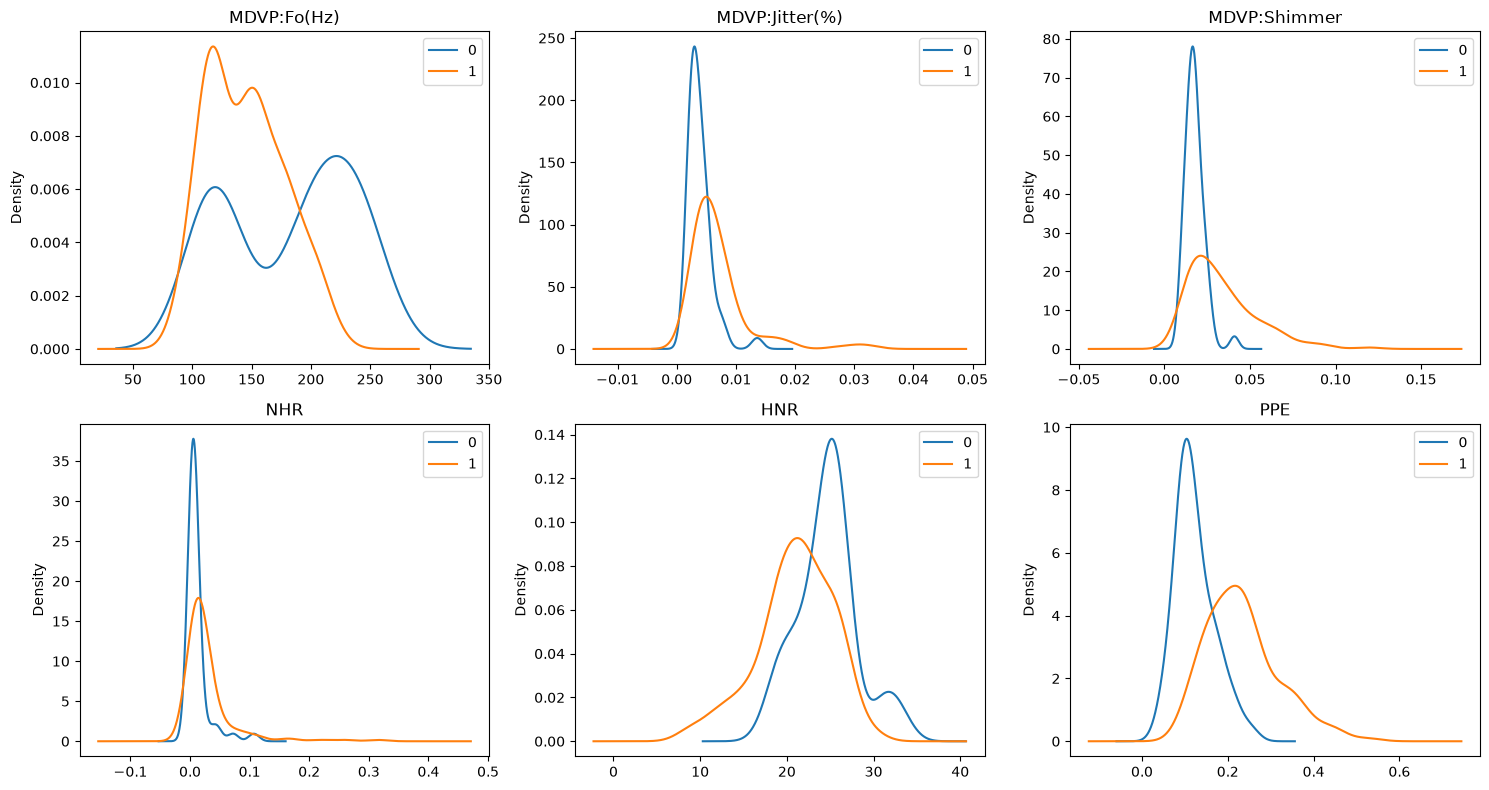

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, col in enumerate(['MDVP:Fo(Hz)','MDVP:Jitter(%)','MDVP:Shimmer','NHR','HNR','PPE']):
    ax = axes[i//3][i%3]
    df.groupby('status')[col].plot(kind='kde', ax=ax, legend=True, title=col)
plt.tight_layout(); plt.show()

## 3 · Feature Engineering & Field Mapping


In [4]:
X = df[['MDVP:Fo(Hz)','MDVP:Jitter(%)','MDVP:Shimmer','NHR','HNR','PPE']].rename(columns={
    'MDVP:Fo(Hz)':'fo_hz','MDVP:Jitter(%)':'jitter_pct','MDVP:Shimmer':'shimmer',
    'NHR':'nhr','HNR':'hnr','PPE':'ppe'})
y = df['status']
print("Class distribution:", y.value_counts().to_dict())

Class distribution: {1: 147, 0: 48}


## 4–5 · Preprocessing & Split 

In [5]:
def make_pipe(clf):
    return Pipeline([('imputer', SimpleImputer(strategy='median')),
                     ('scaler',  StandardScaler()), ('clf', clf)])

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (156, 6), Test: (39, 6)


## 6 · Model Training & Comparison

In [9]:
candidates = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest':       RandomForestClassifier(n_estimators=200, random_state=42),
    'XGBoost':            XGBClassifier(n_estimators=200, random_state=42,
                                        eval_metric='logloss', verbosity=0),
}
results = {}; pipes = {}
for name, clf in candidates.items():
    p = make_pipe(clf); p.fit(X_train, y_train)
    yp = p.predict(X_test); ypr = p.predict_proba(X_test)[:,1]
    results[name] = {'accuracy': round(accuracy_score(y_test,yp),4),
                     'precision': round(precision_score(y_test,yp),4),
                     'recall': round(recall_score(y_test,yp),4),
                     'f1': round(f1_score(y_test,yp),4),
                     'roc_auc': round(roc_auc_score(y_test,ypr),4)}
    pipes[name] = p
pd.DataFrame(results).T.sort_values('roc_auc', ascending=False)

,accuracy,precision,recall,f1,roc_auc
RandomForest,0.9231,0.9643,0.9310,0.9474,0.9793
XGBoost,0.8974,0.9310,0.9310,0.9310,0.9690
LogisticRegression,0.8974,0.9630,0.8966,0.9286,0.9103


## 7 · Evaluation

Best: RandomForest


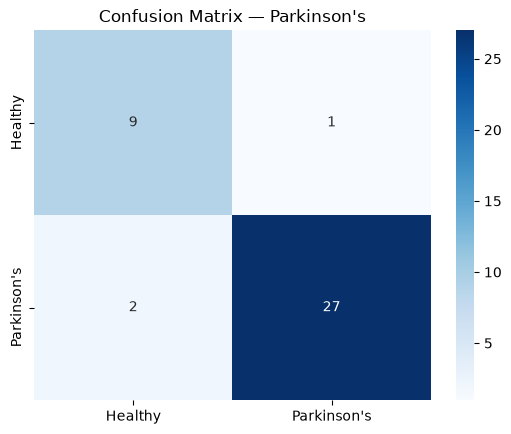

              precision    recall  f1-score   support

     Healthy       0.82      0.90      0.86        10
 Parkinson's       0.96      0.93      0.95        29

    accuracy                           0.92        39
   macro avg       0.89      0.92      0.90        39
weighted avg       0.93      0.92      0.92        39



In [10]:
best_name = max(results, key=lambda k: results[k]['roc_auc'])
best = pipes[best_name]; print(f"Best: {best_name}")
y_pred = best.predict(X_test); y_proba = best.predict_proba(X_test)[:,1]
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy','Parkinson\'s'], yticklabels=['Healthy','Parkinson\'s'])
plt.title('Confusion Matrix — Parkinson\'s'); plt.show()
print(classification_report(y_test, y_pred, target_names=['Healthy','Parkinson\'s']))

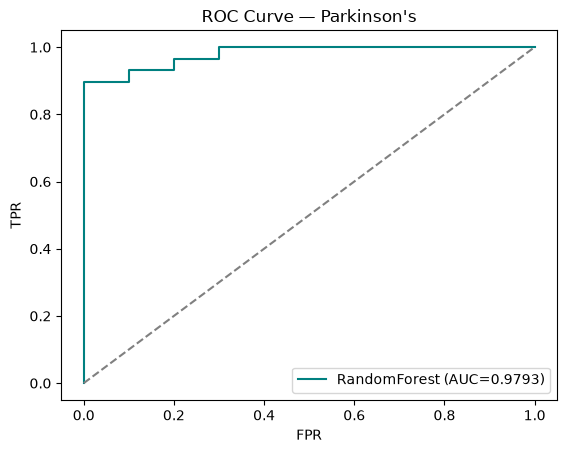

In [11]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f'{best_name} (AUC={results[best_name]["roc_auc"]})', color='teal')
plt.plot([0,1],[0,1],'--',color='grey'); plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('ROC Curve — Parkinson\'s'); plt.legend(); plt.show()

## 8 · Save

In [12]:
joblib.dump(best, '../models/parkinsons_model.joblib')
metrics = {**results[best_name], 'model': best_name,
           'features': list(X.columns), 'test_size': 0.2, 'random_state': 42}
with open('../metrics/parkinsons_metrics.json','w') as f: json.dump(metrics,f,indent=2)